* Name: Arpit Dahyabhai Parmar
* Roll no. : 1200324
* Course: Data Preprocessing
* Assignment Title: Data Preprocessing and Dataset Preparation for Machine Learning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('https://drive.google.com/uc?export=download&id=1D7buBnvpNgFheXj8zVJeI_Um2jyEb3n9')
print('Laptop Dataset loaded')

Laptop Dataset loaded


In [3]:
df.sample(5)

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
1038,1038.0,Dell,Notebook,15.6,Full HD 1920x1080,Intel Core i5 6300U 2.4GHz,8GB,256GB SSD,Intel HD Graphics 520,Windows 7,2.09kg,56633.9760
735,735.0,Lenovo,Notebook,15.6,Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,4GB,1TB HDD,Intel HD Graphics 620,Windows 10,1.85kg,41505.1200
182,182.0,Lenovo,2 in 1 Convertible,13.9,IPS Panel 4K Ultra HD / Touchscreen 3840x2160,Intel Core i7 8550U 1.8GHz,16GB,512GB SSD,Intel UHD Graphics 620,Windows 10,1.4kg,98514.7200
919,919.0,MSI,Gaming,15.6,Full HD 1920x1080,Intel Core i5 7300HQ 2.5GHz,8GB,128GB SSD + 1TB HDD,Nvidia GeForce GTX 1050,Windows 10,2.2kg,59668.8048
588,588.0,Lenovo,Notebook,15.6,Touchscreen 1366x768,Intel Core i7 8550U 1.8GHz,12GB,1TB HDD,Intel HD Graphics 620,Windows 10,2.2kg,32447.5200


In [4]:
df.shape

(1303, 12)

There are 1303 rows and 12 columns in the dataset

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1273 non-null   float64
 1   Company           1273 non-null   object 
 2   TypeName          1273 non-null   object 
 3   Inches            1273 non-null   object 
 4   ScreenResolution  1273 non-null   object 
 5   Cpu               1273 non-null   object 
 6   Ram               1273 non-null   object 
 7   Memory            1273 non-null   object 
 8   Gpu               1273 non-null   object 
 9   OpSys             1273 non-null   object 
 10  Weight            1273 non-null   object 
 11  Price             1273 non-null   float64
dtypes: float64(2), object(10)
memory usage: 122.3+ KB


There are total 12 features in the data set with 1303 records.

# Dataset Understanding

* The LaptopData we're working with is basically a raw, uncleaned dataset of laptop price listings — it contains around 1303 products in total. For each laptop, it gives you details like the brand, type, screen size, resolution, CPU, RAM, storage, GPU, operating system, weight and ofcourse the price.
* Now the dataset have both numerical and categorical columns. The numerical ones includes things like screen size, memory, storage capacity, and price. The categorical side covers stuff like brand, model name, screen resolution, processor type, and operating system — basically all the non-numeric informations.
* The main thing we're trying to predict here is the "Price" column, which is our target variable. Its a continuous variable, meaning it can take any range of values. But here's the catch — the dataset is pretty messy and hasn't been cleaned yet. There's missing values, inconsistent formatting, and some errors here and there that really needs to be fixed before we can actually do any proper analysis or build any kind of model on top of it.

### Column Description

**Unnamed: 0** : It is acting as index for the records.

**Company**: The company of the laptop (e.g., Apple, HP, Acer).

**TypeName**: The type of laptop (e.g., Ultrabook, Notebook, Gaming).

**Inches**: The size of the laptop screen in inches.

**Screen Resolution**: The resolution of the laptop screen.

**CPU**: The processor type and speed (e.g., Intel Core i5 2.3GHz, AMD A9-Series 9420 3GHz).

**RAM (in GB)**: The amount of Random Access Memory (RAM) in gigabytes.

**Memory** : The type of storage device (e.g., SSD, Flash Storage, HDD) and The capacity of the storage device (e.g., 128GB SSD, 500GB HDD).

**GPU**: The Graphics Processing Unit (GPU) and its specifications (e.g., Intel Iris Plus Graphics 640, Nvidia GeForce GTX 1050).

**Operating System**: The operating system pre-installed on the laptop (e.g., macOS, Windows 10, Linux).

**Weight (in kg)**: The weight of the laptop.

**Price**: The price of the laptop.

### Issues with the Dataset

* So out of the 1303 rows, 30 of them are completely missing along with all their 12 columns — the main data quality concern here is clearly completeness.
* No duplicate rows was found, but those 30 rows with all null values are probably result of data entry errors or some missing information somewhere. completeness

**Unnamed: 0:**

* The "Unnamed: 0" column is honestly just useless — its only showing the index of each record and doesn't really add any meaningful information for our analysis. We'll go ahead and drop it to cut down on dimensions and keep things efficient, also helps avoid the Curse of Dimensionality.

**Company:**

* The "Company" column is supposed to have brand names like "Acer", but we also noticed "Vero" in there which is actually just a series under the Acer brand, not a separate company.

**TypeName:**

* No issues were found in the TypeName column, looks fine.

**Inches:**

* All the centimeter (cm) values needs to be converted to inches so that the measurements stays consistent throughout. consistency
* Some values in the "Inches" column shows up as '?' which means the data is either missing or invalid. Validity
* Any Inches column value that are > 18.4 should be manually verified for consistency.

**Ram:**

* The RAM column need to be cleaned so it only keeps the numerical values and removes the 'GB' unit — this makes it easier to work with during analysis. consistency
* There's few RAM sizes in the dataset that just don't really make sense when you compare them with other specs of those laptops. These will need to be manually cross-checked using something like Google to make sure the values are actually accurate. accuracy

**Memory:**

* The '?' entries appearing in the memory column needs to be resolved before moving forward. completeness

**Gpu**

* If we only extract the GPU brand from the 'Gpu' column, we might end up loosing important details about the specific GPU model, which could actually matter when trying to understand how GPU performance relates to laptop pricing. accuracy

**Weight**

* One of the laptops has its weight listed as 0.0002kg which is clearly not right and raises a big red flag about the accuracy of this data. validity
* The weights recorded for Acer, Toshiba and Lenovo laptops seems way higher than what they actually should be. After manually checking on Google, we found the real weights are much lower — Acer should be 2.2kg, Toshiba 1.39kg, and Lenovo 1.27kg. validity

**ScreenResolution**
* The "ScreenResolution" column needs to be splitted into multiple columns so we can separately capture the resolution dimensions and the display type — this will make the data alot more structured and easier to analyze.

**Cpu**

* Similar to ScreenResolution, the "CPU" column should also be broken down into multiple columns so we can properly extract the processor brand, type, and speed without any confusion.

**Memory**

* The memory column is kind of all over the place structurally, so it makes more sense to split it into two separate columns — one for SSD and one for HDD. This way the storage specs becomes much more clearer and easier to compare across different laptops.

**Dataset Description**

| Feature | Attribute Type | Data Type | Description |
| :--- | :--- | :--- | :--- |
| **Unnamed: 0** | Numeric (Discrete) | Integer | Original index identifier from the source CSV file. |
| **Company** | Nominal | String | The laptop manufacturer (e.g., Dell, Apple, HP). |
| **TypeName** | Nominal | String | The category of laptop (e.g., Notebook, Gaming, Ultrabook). |
| **Inches** | Numeric (Continuous)| Float | The diagonal screen size of the laptop in inches. |
| **ScreenResolution**| Nominal | String | Raw text containing display resolution and panel technology details. |
| **Cpu** | Nominal | String | Raw text describing the Central Processing Unit brand, model, and speed. |
| **Ram** | Numeric (Discrete)| String | The amount of Random Access Memory (e.g., '8GB'). |
| **Memory** | Nominal | String | Combined text for storage type and capacity (e.g., '256GB SSD'). |
| **Gpu** | Nominal | String | The Graphics Processing Unit specifications. |
| **OpSys** | Nominal | String | The pre-installed Operating System (e.g., Windows 10, macOS). |
| **Weight** | Numeric (Continuous)| String | The physical mass of the laptop with units (e.g., '1.3kg'). |
| **Price** | Numeric (Continuous) | Float | The sale price of the laptop (Target Variable). |

# Data Quality Analysis

## Missing Value Analysis

In [6]:
df.isnull().sum()

,0
Unnamed: 0,30
Company,30
TypeName,30
Inches,30
ScreenResolution,30
Cpu,30
Ram,30
Memory,30
Gpu,30
OpSys,30


There are 30 missing value in each column. Let's see if it's the same row for all or is it different rows for each missing value. This will help us to take appropriate action to fill these or remove the entire rows if all the missing values in the same row.

In [7]:
pd.set_option('display.max_rows', None)

In [8]:
df[df.isnull().any(axis=1)]

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
46,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
115,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
125,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
148,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
190,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
209,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
267,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
336,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


All Missing Values exists in a 30 rows. Thus there is no point or sense to impute missing values for these row as the whole rows are empty.

Thus its better to remove these rows.

In [9]:

df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
print('Missing values removed and index reset')

Missing values removed and index reset


In [10]:
print('The updated shape of the data after removing the empty row with all missing values is : ', df.shape)

The updated shape of the data after removing the empty row with all missing values is :  (1273, 12)


## Duplicate Data analysis



In [11]:
df.duplicated().sum()

np.int64(0)

There are no duplicate records in the data.


## Outlier / Noise in Data Analysis

**Outlier Analysis**

As we examine the data through the lens of robust statistical analysis, our primary objective in the outlier detection phase was to distinguish between 'noise' and 'legitimate variance' (extreme but valid observations).

Outlier Analysis

1. Distributional Characteristics: Our initial exploratory analysis of the Price target variable revealed a significant positive skew (right-skewed). Given that the data does not follow a Gaussian distribution, the application of Z-score normalization would be inappropriate as it assumes symmetry. Consequently, we employed the Interquartile Range (IQR) Method, a non-parametric approach that is resilient to skewed distributions.

2. Statistical Identification: Using the standard Tukey’s fences, we calculated the upper bound as follows:

* Q1 (25th Percentile): 31,914.72
* Q3 (75th Percentile): 79,333.39
* IQR: 47,418.67
* Upper Bound (Q3 + 1.5 * IQR): 150,461.39

* This identified 28 observations exceeding the threshold.

3. Qualitative Validation and Retention Strategy: A granular inspection of these 28 records (including brands like Razer and specialized Dell Workstations) confirms that these data points correlate with high-performance hardware specifications—such as 4K displays, Intel Xeon processors, and high-tier GPUs.

Conclusion: From a modeling perspective, these are not 'errors' but represent the high-end segment of the market. Removing them would introduce selection bias and diminish the model's ability to generalize across the full spectrum of laptop pricing. Therefore, we will retain these 'influential observations' to ensure our eventual regressor captures the non-linear relationship between premium specifications and price.

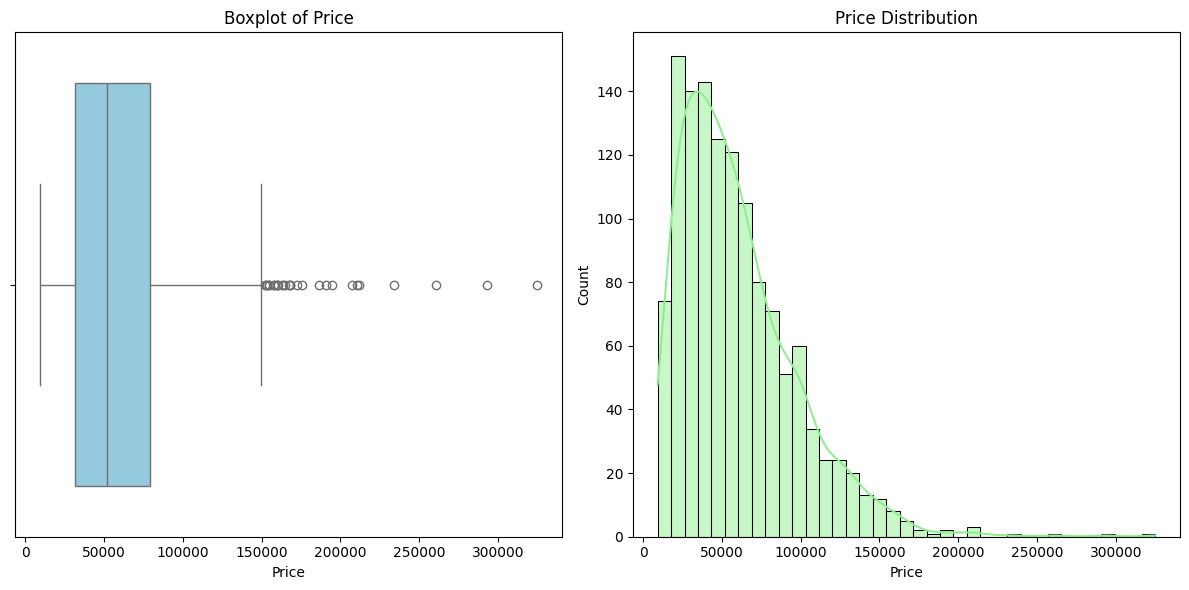

In [12]:
fig, ax = plt.subplots(1,2, figsize=(12, 6))
sns.boxplot(data=df, x='Price', color='skyblue', ax=ax[0])
ax[0].set_title('Boxplot of Price')
sns.histplot(data=df, x='Price', kde=True, color='lightgreen', ax=ax[1])
ax[1].set_title('Price Distribution')
plt.tight_layout()

The price distribution is right skewed and not normally distributed. Thus, it is not a favourable condition to use z-score to analyse the noise or outliers

Using IQR method to analyse noise & outliers will be the idle option.

In [13]:
# IQR method to find noise

Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

noise = df[(df['Price']< lower_bound) | (df['Price']>upper_bound)]

In [14]:
noise.shape

(28, 12)

28 records are found to be noise or outliers.

We will have a look into these 28 records to determine whether these are outliers or noise.

In [15]:
noise

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
17,17.0,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.9GHz,16GB,512GB SSD,AMD Radeon Pro 560,macOS,1.83kg,152274.2400
189,196.0,Razer,Gaming,17.3,4K Ultra HD / Touchscreen 3840x2160,Intel Core i7 7820HK 2.9GHz,32GB,1TB SSD,Nvidia GeForce GTX 1080,Windows 10,3.49kg,324954.7200
197,204.0,Dell,Workstation,15.6,4K Ultra HD 3840x2160,Intel Xeon E3-1505M V6 3GHz,16GB,256GB SSD + 1TB HDD,Nvidia Quadro M1200,Windows 10,2.8kg,162770.4000
230,238.0,Asus,Gaming,17.3,Full HD 1920x1080,Intel Core i7 7820HK 2.9GHz,32GB,512GB SSD + 1TB HDD,Nvidia GeForce GTX 1080,Windows 10,4.7kg,207259.2000
239,247.0,Asus,Gaming,17.3,Full HD 1920x1080,Intel Core i7 7820HK 2.9GHz,16GB,256GB SSD,Nvidia GeForce GTX 1080,Windows 10,3.6kg,159786.7200
288,297.0,Dell,Workstation,17.3,Full HD 1920x1080,Intel Core i7 7820HQ 2.9GHz,16GB,256GB SSD,Nvidia Quadro M1200,Windows 10,3.42kg,153705.3408
505,517.0,Asus,Gaming,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,24GB,512GB SSD,Nvidia GeForce GTX1080,Windows 10,2.24kg,158135.0400
518,530.0,Dell,Gaming,17.3,IPS Panel Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,128GB SSD + 1TB HDD,Nvidia GeForce GTX 1070,Windows 10,4.42kg,160520.3856
551,563.0,Lenovo,Notebook,17.3,IPS Panel Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,8GB,256GB SSD,Nvidia Quadro M620M,Windows 10,3.4kg,159786.7200
597,610.0,Lenovo,Notebook,15.6,IPS Panel 4K Ultra HD 3840x2160,Intel Xeon E3-1535M v6 3.1GHz,32GB,1TB SSD,Nvidia Quadro M2200M,Windows 10,2.5kg,261018.7200


These all seems to be legitimate records and are aligning with the real world laptop prices. Thus these should be categorised as outliers and not noise.

These points are to be kept and not discarded as these are legitimate. Keeping these points in the dataset will help the model with the consideration of these high end laptop specifications and price category, indeed helping model in predicting prices of the laptop.

# Data Cleaning

## Handling Missing Values

From the perspective of data integrity and statistical validity, our preliminary diagnostic phase revealed a critical completeness issue within the dataset.

Missing Value Analysis

1. Diagnostic Identification: Upon executing a null-value audit (df.isnull().sum()), we detected 30 observations where every single feature—including the target variable Price—was null. This suggests a systemic data entry failure rather than a stochastic process (MCAR/MAR).

2. Strategy Selection: Case Deletion vs. Imputation: In advanced predictive modeling, imputation (e.g., Mean/Median or MICE) is generally preferred to preserve sample size. However, in this specific instance, we opted for Listwise Deletion (Case Deletion) for the following reasons:

* Total Information Loss: Since the entire feature vector for these 30 records was missing, there was no 'auxiliary information' or correlation available to inform a reliable imputation.
* Target Leakage and Bias: Imputing the dependent variable (Price) alongside all independent variables would introduce significant 'synthetic noise.' This would likely lead to artificial shrinkage of variance and potentially bias the model's coefficients during the regression phase.
* Data Quality Threshold: These rows represented 'ghost records' rather than incomplete observations.

Conclusion: By removing these 30 rows, we reduced the dataset to 1,273 high-fidelity records. This ensures that the training phase is conducted on legitimate empirical data, maintaining the structural integrity of the feature space without the dilution inherent in high-entropy imputation.

## Duplicated Values


From a data integrity perspective, after addressing the initial completeness issues, we conducted a rigorous audit for redundant observations.

Duplicate Data Analysis

1. Diagnostic Methodology: Following the removal of the 30 null-entry 'ghost records,' we applied the .duplicated() boolean indexing method across the entire feature space. This audit was designed to identify any identical row-wise vectors that could artificially inflate certain data distributions or lead to overfitting during the model training phase.

2. Findings and Interpretation: The audit returned a count of zero duplicates. This is a significant finding for several reasons:

  * Uniqueness of Observations: Each listing in the 1,273-record subset represents a unique combination of hardware specifications, manufacturer branding, and pricing, suggesting a high degree of granularity in the data collection process.

  * Mitigation of Bias: The absence of duplicates ensures that the eventual regression coefficients will not be disproportionately influenced by repeated observations, thereby maintaining the statistical independence of our samples.
  
  * Data Reliability: While the initial dataset exhibited 'messy' characteristics, the lack of duplicate records indicates that the primary data quality challenges are structural (formatting) rather than operational (repeated entries).

Conclusion: The dataset, in its current state, demonstrates high internal validity regarding record uniqueness. This allows us to proceed to the feature engineering phase with confidence that each data point provides distinct information for predictive analysis.



## Fixing Inconsistent Data

### Unnamed: 0

'Unnamed' is a column which is an index for this dataset. It will not add up any useful information, thus we will remove this column to help dimensionality reduction.

In [16]:
df.drop('Unnamed: 0', axis=1, inplace=True)

### Company

In [17]:
df['Company'].value_counts()

,count
Company,
Lenovo,290
Dell,287
HP,266
Asus,156
Acer,103
MSI,53
Toshiba,47
Apple,21
Samsung,9


As "Vero" is not a standalone brand & is a model series of Acer brand, indicating a consistency issue.

Replacing "Vero" with "Acer"

In [18]:
df[(df['Company']== 'Vero')]

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
184,Vero,Notebook,14,IPS Panel Full HD 1920x1080,Intel Celeron Dual Core N3350 1.1GHz,4GB,32GB Flash Storage,Intel HD Graphics 500,Windows 10,1.3kg,13852.800
769,Vero,Notebook,14,1920x1080,Intel Celeron Dual Core N3350 1.1GHz,4GB,32GB Flash Storage,Intel HD Graphics 500,Windows 10,1.22kg,10810.512
1014,Vero,Notebook,14,1366x768,Intel Atom X5-Z8350 1.44GHz,2GB,32GB Flash Storage,Intel HD Graphics 400,Windows 10,1.45kg,11231.424
1092,Vero,Notebook,13.3,Full HD 1920x1080,Intel Atom X5-Z8350 1.44GHz,4GB,32GB Flash Storage,Intel HD Graphics 400,Windows 10,1.35kg,10442.880


In [19]:
df.loc[df['Company']== 'Vero', 'Company'] = 'Acer'

Company name "Vero" is replaced by 'Acer'

### TypeName

In [20]:
df['TypeName'].value_counts()

,count
TypeName,
Notebook,710
Gaming,203
Ultrabook,191
2 in 1 Convertible,116
Workstation,29
Netbook,24


TypeName is consistent and seems to be correct.

### Inches

In [21]:
df['Inches'].value_counts()

,count
Inches,
15.6,640
14,192
17.3,162
13.3,161
12.5,38
11.6,31
12,6
13.9,6
13.5,5


In [22]:
df[(df['Inches']=='?')]

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
465,Dell,Workstation,?,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,8GB,256GB SSD,Nvidia Quadro M1200,Windows 10,1.78kg,128298.24


There is a '?' character exists in the inches column. It indicates a missing value.

As the other fields in this row vector is available, thus this missing field can be computed.

Let's first address it as nan value, then will impute

In [23]:
df.loc[df['Inches']=='?', 'Inches'] = np.nan

Converting "Inches" column to float to impute missing value

In [24]:
df['Inches'] = df['Inches'].astype(float)

Imputing this missing value using mean imputation but with consideration of other specifications such as company, TypeName, screenResolution, Cpu and Ram.

Keeping all those factors in consideration the imputed value is so legit to the real world observation.

In [25]:
df['Inches'] = df['Inches'].fillna(df.groupby(['Company', 'TypeName',
  'ScreenResolution', 'Cpu', 'Ram'])['Inches'].transform('mean'))

Imputed the missing value successfully and in a very efficient and consistent manner.

In [26]:
df["Inches"].value_counts()

,count
Inches,
15.6,641
14.0,192
17.3,162
13.3,161
12.5,38
11.6,31
13.9,6
12.0,6
12.3,5


In [27]:
df.iloc[465]

,465
Company,Dell
TypeName,Workstation
Inches,15.6
ScreenResolution,Full HD 1920x1080
Cpu,Intel Core i7 7700HQ 2.8GHz
Ram,8GB
Memory,256GB SSD
Gpu,Nvidia Quadro M1200
OpSys,Windows 10
Weight,1.78kg


<Axes: xlabel='Inches', ylabel='Count'>

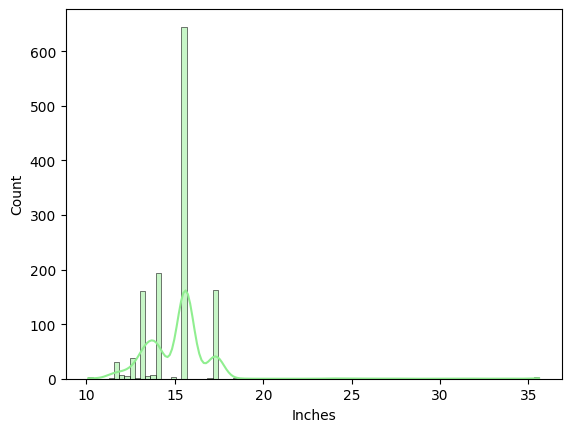

In [28]:
sns.histplot(data=df, x='Inches', kde=True, color='lightgreen')

In [29]:
Q1_inches = df['Inches'].quantile(0.25)
Q3_inches = df['Inches'].quantile(0.75)

IQR_inches = Q3_inches - Q1_inches

lower_bound_inches = Q1_inches - 1.5 * IQR_inches
upper_bound_inches = Q3_inches + 1.5 * IQR_inches

outliers_inches = df[(df['Inches'] < lower_bound_inches) | (df['Inches'] > upper_bound_inches)]

In [30]:
print("Lower_bound : ", lower_bound_inches)
print("upper_bound", upper_bound_inches)
outliers_inches.shape

Lower_bound :  11.600000000000001
upper_bound 18.0


(45, 11)

There exist 45 noise in "Inches" column. However, The values which is at the lowest is 10.1 and the lower values than lower bound, are legitimate sizes in inch according to the market.

However those laptops with sizes greater than upper_bound is quite unreal to be in inches unit. sizes post 18.4, must be in Centimeter unit, that should be converted to inches unit for consistency.

In [31]:
outliers_inches['Inches'].min()

10.1

The minimum screen size in outliers is 10.1, which seems legit. Thus we will ignore this and focus in values greater than upper_bound.

In [32]:
outliers_inches = df[(df['Inches'] > 18.4)]

In [33]:
outliers_inches['Inches'].value_counts()

,count
Inches,
35.6,3
24.0,2
25.6,1
27.3,1
33.5,1
31.6,1


Converting these centimetre sizes to inch unit.

In [34]:
df.loc[df['Inches']>18.4, 'Inches'] = round(df['Inches']/2.54, 1)

All the records in "Inches" field is converted to inches improving the consistency in the data.

The noise in inches column have been handled well by converting it to the appropriate unit.

### Ram

In [35]:
df['Ram'].value_counts()

,count
Ram,
8GB,601
4GB,367
16GB,194
6GB,40
12GB,25
2GB,22
32GB,17
64GB,3
24GB,3


We can improve this column consistency and interpretability by removing the GB text and converting the column to numeric.

In [36]:
df.loc[df['Ram']=='1GB']

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
688,Acer,2 in 1 Convertible,13.3,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i5 8250U 1.6GHz,1GB,256GB SSD,Intel UHD Graphics 620,Windows 10,1.6kg,53226.72


For this particular record, I googled and found out that this unit comes with 8GB of RAM, thus updating it with 8GB.

This also indicates inaccuracy which has to be considered and a strong indication to recheck the data values.

In [37]:
df.loc[df['Ram']=='1GB', 'Ram'] = '8GB'

In [38]:
df['Ram'] = df['Ram'].str.strip('GB')

Removed GB text, and retained only the numeric value.

In [39]:
df['Ram'] = df['Ram'].astype(int)

Converted Ram column to a numeric datatype.

### Memory

In [40]:
df['Memory'].value_counts()

,count
Memory,
256GB SSD,401
1TB HDD,217
500GB HDD,130
512GB SSD,116
128GB SSD + 1TB HDD,92
128GB SSD,74
256GB SSD + 1TB HDD,71
32GB Flash Storage,37
2TB HDD,16


There is a "?" character in the Memory column, indicating a missing value. Thus we will replace it with nan and then will impute the value using appropriate method.

In [41]:
df.loc[df['Memory'] == '?']

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
749,Dell,Notebook,15.6,Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,16,?,AMD Radeon R7 M445,Windows 10,2.3kg,62938.0656


In [42]:
df.loc[df['Memory'] == '?', 'Memory'] = np.nan

We will use imputation using mode as it is a categorical variable, and hence that will be the suitable method.
However, we will not only use mode imputation but also couple it with another approach by leveraging information from other variables to improve accuracy of the imputed value.

In [43]:
df['Memory'] = df['Memory'].fillna(df.groupby(['Company', 'TypeName',
  'ScreenResolution', 'Cpu', 'Ram'])['Memory'].transform(
      lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan))

In [44]:
df.loc[749]

,749
Company,Dell
TypeName,Notebook
Inches,15.6
ScreenResolution,Full HD 1920x1080
Cpu,Intel Core i7 7500U 2.7GHz
Ram,16
Memory,256GB SSD
Gpu,AMD Radeon R7 M445
OpSys,Windows 10
Weight,2.3kg


Imputed the missing value in Memory column.

### GPU

In [45]:
df['Gpu'].value_counts()

,count
Gpu,
Intel HD Graphics 620,271
Intel HD Graphics 520,181
Intel UHD Graphics 620,66
Nvidia GeForce GTX 1050,64
Nvidia GeForce GTX 1060,48
Nvidia GeForce 940MX,42
AMD Radeon 530,39
Intel HD Graphics 500,39
Intel HD Graphics 400,34


In Gpu column, there is no special character (missing value). We can keep the GPU brand name only such as AMD, Nvidia, Intel, but that will result in some information loss pf the particular model of Gpu. Therefore, we will keep this column as it is.

### OpSys

In [46]:
df['OpSys'].value_counts()

,count
OpSys,
Windows 10,1047
No OS,63
Linux,61
Windows 7,45
Chrome OS,27
macOS,13
Mac OS X,8
Windows 10 S,8
Android,1


Operating System data looks fine and good to go with.

### Weight

In [47]:
df['Weight'].value_counts()

,count
Weight,
2.2kg,111
2.1kg,57
2.4kg,43
2.3kg,41
2.5kg,37
2kg,32
2.8kg,27
1.2kg,25
1.86kg,23


There is one special character '?' which is to be handled.

Some weights are unreal for example 0.002Kg, and some are on the very high side.

As all of the weights are having unit as KG, so let's first remove the KG text, and convert this column to numeric and also will impute the missing value.

In [48]:
df.loc[df['Weight']=='?']

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
201,Dell,Ultrabook,13.3,Full HD 1920x1080,Intel Core i7 8550U 1.8GHz,8,256GB SSD,Intel UHD Graphics 620,Windows 10,?,77202.72


In [49]:
df['Weight'] = df['Weight'].str.strip('kg')

Removed "kg" text from the values.

Replacing "?" to np.nan, so that we can impute it.

In [50]:
df.loc[df['Weight']=='?', 'Weight'] = np.nan

In [51]:
df['Weight'] = round(pd.to_numeric(df['Weight']),2)

Weight column is converted to float datatype.

As it is converted to numeric column, thus we can now impute the missing value

In [52]:
df.sample()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
435,Acer,Notebook,15.6,1366x768,Intel Core i5 7200U 2.5GHz,4,500GB HDD,Intel HD Graphics 620,Linux,2.4,23539.104


In [53]:
df['Weight'] = df['Weight'].fillna(df.groupby(["Company", "TypeName", "Inches","ScreenResolution",
                                               "Cpu", "Ram", "Memory"])['Weight'].transform(lambda x : x.mean()))

In [54]:
df.loc[201]

,201
Company,Dell
TypeName,Ultrabook
Inches,13.3
ScreenResolution,Full HD 1920x1080
Cpu,Intel Core i7 8550U 1.8GHz
Ram,8
Memory,256GB SSD
Gpu,Intel UHD Graphics 620
OpSys,Windows 10
Weight,1.2


We have coupled mean imputation with the group by method to improve the accuracy of the imputed value with the help of specs of particular segment of laptops.

Now let's address the weights which look unreal

<Axes: xlabel='Weight'>

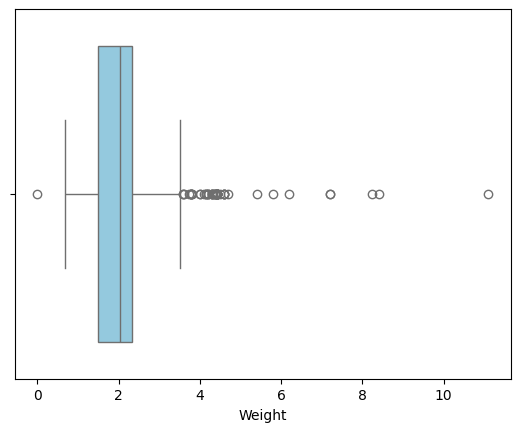

In [55]:
sns.boxplot(data=df, x='Weight', color='skyblue')

It is clearly evident through boxplot analysis that there are definitely outliers, which needs to be addressed.

In [56]:
Q1_weight = df['Weight'].quantile(0.25)
Q3_weight = df['Weight'].quantile(0.75)

IQR_weight = Q3_weight - Q1_weight

lower_bound_weight = Q1_weight - 1.5 * IQR_weight
upper_bound_weight = Q3_weight + 1.5 * IQR_weight

outliers_weight = df[(df['Weight'] < lower_bound_weight) | (df['Weight'] > upper_bound)]

In [57]:
print("Lower_bound : ", lower_bound_weight)
print("upper_bound", upper_bound_weight)

Lower_bound :  0.27000000000000024
upper_bound 3.55


In [58]:
outliers_weight = df[(df['Weight'] < lower_bound_weight) | (df['Weight'] > upper_bound)]

According to the research, the most light weight laptop ever built has weight 860 gram and it holds guiness world record for that, and that is of the brand LG.

On the contrary, the most heavy weight laptop ever built has weight 4.5 Kg, and exception for ACER predator to be 8.5 KG that too is for gaming laptops, as they come up with heavy processors, cooling technical equipments and many more things, particulary this most heavy ones are from Acer Predator series, Dell XPS series, MSI, Asus gaming laptops.

In [59]:
df.loc[(df['Weight']>5) | (df['Weight']<0.8)]

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
128,Acer,Notebook,15.6,Full HD 1920x1080,Intel Core i3 7130U 2.7GHz,4,256GB SSD,Nvidia GeForce MX130,Windows 10,7.20,30476.1600
167,Toshiba,Notebook,15.6,1366x768,Intel Core i3 7100U 2.4GHz,4,500GB HDD,Intel HD Graphics 620,Windows 10,5.40,26053.9200
232,Lenovo,Notebook,15.6,1366x768,Intel Core i3 6006U 2GHz,8,128GB SSD,Intel HD Graphics 520,Windows 10,7.20,31381.9200
293,Lenovo,Notebook,17.3,1600x900,Intel Core i5 7200U 2.5GHz,6,1TB HDD,Nvidia GeForce GTX 940M,Windows 10,5.80,34578.7200
317,Acer,Notebook,15.6,1366x768,Intel Core i5 7200U 2.5GHz,6,1TB HDD,Intel HD Graphics 620,Windows 10,8.23,29250.7200
339,Dell,Ultrabook,15.6,Full HD 1920x1080,Intel Core i5 8250U 1.6GHz,8,1TB HDD,AMD Radeon 530,Windows 10,0.00,35324.6400
574,Lenovo,Ultrabook,14.0,IPS Panel Full HD 1920x1080,Intel Core i7 6600U 2.6GHz,12,256GB SSD,Intel HD Graphics 520,Windows 10,8.40,89137.4400
614,Asus,Ultrabook,14.0,Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,16,512GB SSD,Intel HD Graphics 620,Windows 10,11.10,101232.0000
640,Dell,Notebook,15.6,Full HD 1920x1080,Intel Core i7 8550U 1.8GHz,8,256GB SSD,AMD Radeon 530,Windows 10,6.20,48964.3200
1054,Lenovo,2 in 1 Convertible,10.1,IPS Panel Touchscreen 1920x1200,Intel Atom x5-Z8550 1.44GHz,4,64GB Flash Storage,Intel HD Graphics 400,Windows 10,0.69,34433.2656


In [60]:
df.loc[(df['Weight']>5) | (df['Weight']<0.8)].shape

(12, 11)

These 12 records of weights are quite unreal raising accuracy concerns.

There is one record which is having weight as 0.0002 kg, and one that is having 11.10 Kg weight which are undoubtedly noise. Thus, we will impute those to correct value.

In [61]:
df.loc[df['Weight']==0.00, 'Weight'] = np.nan

In [62]:
df.loc[df['Weight']==11.10, 'Weight'] = np.nan

In [63]:
df['Weight'].isna().sum()

np.int64(2)

In [64]:
df['Weight'] = df['Weight'].fillna(df.groupby(["Company", "TypeName", "Inches",
                                               "Cpu"])['Weight'].transform(lambda x : x.mean()))

In [65]:
df['Weight'].isnull().sum()

np.int64(0)

Imputed the nearly accurate values in place of the noisy values in weight column

### ScreenResolution

In [66]:
df['ScreenResolution'].value_counts()

,count
ScreenResolution,
Full HD 1920x1080,495
1366x768,274
IPS Panel Full HD 1920x1080,226
IPS Panel Full HD / Touchscreen 1920x1080,52
Full HD / Touchscreen 1920x1080,45
1600x900,23
Touchscreen 1366x768,16
Quad HD+ / Touchscreen 3200x1800,14
IPS Panel 4K Ultra HD 3840x2160,12


Dividing this column into two columns with one column having screen type name & the other column having screen resolution

In [67]:
df['ScreenResolution_new'] = df['ScreenResolution'].str.extract(r'(\d+x\d+)')
df['ScreenType'] = df['ScreenResolution'].str.replace(r'(\d+x\d+)', '', regex=True).str.strip()
df['ScreenResolution'] = df['ScreenResolution_new']
df.drop('ScreenResolution_new', axis=1, inplace=True)

Splitted ScreenResolution column into two columns : "ScreenType" and "ScreenResolution"

In [68]:
df.sample()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,ScreenType
1240,Lenovo,2 in 1 Convertible,14.0,1920x1080,Intel Core i7 6500U 2.5GHz,4,128GB SSD,Intel HD Graphics 520,Windows 10,1.8,33992.64,IPS Panel Full HD / Touchscreen


Putting ScreenType column at 3rd column position, just before ScreenResolution column

In [69]:
df.insert(3, 'ScreenType', df.pop('ScreenType'))

In [70]:
df['ScreenType'].value_counts()

,count
ScreenType,
Full HD,495
,307
IPS Panel Full HD,231
IPS Panel Full HD / Touchscreen,52
Full HD / Touchscreen,45
Touchscreen,31
IPS Panel Retina Display,17
Quad HD+ / Touchscreen,14
IPS Panel 4K Ultra HD,12


Imputing the blank values in ScreenType column with mode imputation coupled with groupby other columns to form clusters of similar laptops and then imputing on based of those.

In [71]:
df.loc[df['ScreenType']=="", 'ScreenType'] = np.nan

In [72]:
df['ScreenType'].isna().sum()

np.int64(307)

In [73]:
df['ScreenType'] = df['ScreenType'].fillna(df.groupby(['Company', 'TypeName', 'Inches', 'ScreenResolution'])['ScreenType'].transform(lambda x: x.mode()[0] if not x.mode().empty else np.nan))

In [74]:
df['ScreenType'].isna().sum()

np.int64(126)

In [75]:
df['ScreenType'] = df['ScreenType'].fillna(df.groupby(['Company', 'TypeName', 'ScreenResolution'])['ScreenType'].transform(lambda x: x.mode()[0] if not x.mode().empty else np.nan))

In [76]:
df['ScreenType'].isna().sum()


np.int64(84)

In [77]:
df['ScreenType'] = df['ScreenType'].fillna(df.groupby(['Company', 'TypeName'])['ScreenType'].transform(lambda x: x.mode()[0] if not x.mode().empty else np.nan))

In [78]:
df['ScreenType'].isna().sum()

np.int64(8)

In [79]:
df['ScreenType'] = df['ScreenType'].fillna(df.groupby(['Company'])['ScreenType'].transform(lambda x: x.mode()[0] if not x.mode().empty else np.nan))

In [80]:
df['ScreenType'].isna().sum()

np.int64(2)

In [81]:
df['ScreenType'] = df['ScreenType'].fillna(df.groupby(['TypeName'])['ScreenType'].transform(lambda x: x.mode()[0] if not x.mode().empty else np.nan))

In [82]:
df['ScreenType'].isna().sum()

np.int64(0)

We used Iterative approach of selecting subsets of columns to take help of to impute values in newly created ScreenType column values.

All missing values in ScreenType column are imputed now

In [83]:
df['ScreenType'].value_counts()

,count
ScreenType,
Full HD,574
IPS Panel Full HD,232
Touchscreen,178
IPS Panel,85
IPS Panel Full HD / Touchscreen,52
Full HD / Touchscreen,45
IPS Panel Retina Display,22
Quad HD+ / Touchscreen,14
IPS Panel 4K Ultra HD,12


### Cpu

In [84]:
df['Cpu'].value_counts()

,count
Cpu,
Intel Core i5 7200U 2.5GHz,183
Intel Core i7 7700HQ 2.8GHz,142
Intel Core i7 7500U 2.7GHz,128
Intel Core i7 8550U 1.8GHz,72
Intel Core i5 8250U 1.6GHz,68
Intel Core i5 6200U 2.3GHz,66
Intel Core i3 6006U 2GHz,62
Intel Core i7 6500U 2.5GHz,49
Intel Core i7 6700HQ 2.6GHz,43


Transforming the "CPU" column into multiple columns, facilitating accurate extraction of processor brand, type, and speed.

In [85]:
df['Cpu_brand'] = df['Cpu'].str.split(" ").str.get(0)


In [86]:
df['Cpu_speed'] = df['Cpu'].apply(lambda x: x.split()[-1])
df['Cpu_speed'] = df['Cpu_speed'].str.replace("GHz", "")
df['Cpu_speed'] = pd.to_numeric(df['Cpu_speed'])

In [87]:
df['Cpu_type'] = df['Cpu'].apply(lambda x: ' '.join(x.split()[1:-1]))

In [88]:
df.sample()

,Company,TypeName,Inches,ScreenType,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Cpu_brand,Cpu_speed,Cpu_type
1024,HP,Notebook,15.6,IPS Panel Full HD,1920x1080,Intel Core i7 7500U 2.7GHz,8,1TB HDD,Nvidia GeForce 940MX,Windows 10,1.91,52161.12,Intel,2.7,Core i7 7500U


Droping Cpu column and keeping Cpu_brand, Cpu_speed , Cpu_type in place.

In [89]:
df.drop('Cpu', axis=1, inplace=True)

In [90]:
df.insert(5, 'Cpu_brand', df.pop('Cpu_brand'))
df.insert(6, 'Cpu_speed', df.pop('Cpu_speed'))
df.insert(7, 'Cpu_type', df.pop('Cpu_type'))

In [91]:
df.sample()

,Company,TypeName,Inches,ScreenType,ScreenResolution,Cpu_brand,Cpu_speed,Cpu_type,Ram,Memory,Gpu,OpSys,Weight,Price
612,Lenovo,Notebook,15.6,Full HD,1920x1080,Intel,2.5,Core i5 7200U,4,128GB SSD,Intel HD Graphics 620,No OS,2.2,24935.04


In [92]:
df['Cpu_speed'].value_counts()

,count
Cpu_speed,
2.50,286
2.80,161
2.70,160
1.60,129
2.30,84
2.00,84
1.80,77
2.60,75
1.10,53


In [93]:
df['Cpu_type'].value_counts()

,count
Cpu_type,
Core i5 7200U,186
Core i7 7700HQ,143
Core i7 7500U,129
Core i3 6006U,79
Core i7 8550U,72
Core i5 8250U,68
Core i5 6200U,66
Core i7 6500U,51
Core i7 6700HQ,43


### Memory

Distributing Memory into 3 categories of storage : SSD_Storage, HDD_storage and Flash_Storage, to facilitate interpretability and reducing complexity

In [94]:
import re

In [95]:
def categorize_memory(memory_str):
    ssd = 0
    hdd = 0
    flash = 0

    if isinstance(memory_str, float) and pd.isna(memory_str):
        return 0, 0, 0

    memory_str = str(memory_str).replace('GB', '').replace('TB', '000').replace(' ', '')

    if 'SSD' in memory_str:
        ssd_match = re.search(r'(\d+)SSD', memory_str)
        if ssd_match:
            ssd = int(ssd_match.group(1))
    if 'HDD' in memory_str:
        hdd_match = re.search(r'(\d+)HDD', memory_str)
        if hdd_match:
            hdd = int(hdd_match.group(1))
    if 'FlashStorage' in memory_str:
        flash_match = re.search(r'(\d+)FlashStorage', memory_str)
        if flash_match:
            flash = int(flash_match.group(1))

    return ssd, hdd, flash

# Apply the function to create new columns
df[['SSD_Storage', 'HDD_storage', 'Flash_Storage']] = df['Memory'].apply(lambda x: pd.Series(categorize_memory(x)))

display(df.head())

,Company,TypeName,Inches,ScreenType,ScreenResolution,Cpu_brand,Cpu_speed,Cpu_type,Ram,Memory,Gpu,OpSys,Weight,Price,SSD_Storage,HDD_storage,Flash_Storage
0,Apple,Ultrabook,13.3,IPS Panel Retina Display,2560x1600,Intel,2.3,Core i5,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,128,0,0
1,Apple,Ultrabook,13.3,IPS Panel Retina Display,1440x900,Intel,1.8,Core i5,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,128
2,HP,Notebook,15.6,Full HD,1920x1080,Intel,2.5,Core i5 7200U,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,256,0,0
3,Apple,Ultrabook,15.4,IPS Panel Retina Display,2880x1800,Intel,2.7,Core i7,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,512,0,0
4,Apple,Ultrabook,13.3,IPS Panel Retina Display,2560x1600,Intel,3.1,Core i5,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,256,0,0


In [96]:
df.drop('Memory', axis=1, inplace=True)

In [97]:
df.insert(9, 'SSD_Storage', df.pop('SSD_Storage'))
df.insert(10, 'HDD_storage', df.pop('HDD_storage'))
df.insert(11, 'Flash_Storage', df.pop('Flash_Storage'))

In [98]:
df.sample()

,Company,TypeName,Inches,ScreenType,ScreenResolution,Cpu_brand,Cpu_speed,Cpu_type,Ram,SSD_Storage,HDD_storage,Flash_Storage,Gpu,OpSys,Weight,Price
893,Lenovo,Notebook,13.3,Full HD,1920x1080,Intel,2.5,Core i5 7200U,4,128,0,0,Intel HD Graphics 620,Windows 10,1.44,46939.68


# Data Transformation

## Encoding Categorical Variable

In [99]:
df['ScreenResolution'].value_counts().sort_index()

,count
ScreenResolution,
1366x768,301
1440x900,4
1600x900,23
1920x1080,822
1920x1200,4
2160x1440,2
2256x1504,6
2304x1440,6
2400x1600,4


### Hybrid Encoding Strategy
In this section, we apply different encoding techniques based on the nature and cardinality of each categorical feature.

In [100]:
# 1. Ordinal Encoding for ScreenType
# We define a hierarchy based on display quality/technology
screen_map = {
    'IPS Panel Retina Display': 4,
    '4K Ultra HD': 4,
    'IPS Panel 4K Ultra HD': 4,
    'IPS Panel 4K Ultra HD / Touchscreen': 4,
    '4K Ultra HD / Touchscreen': 4,
    'Quad HD+': 3,
    'IPS Panel Quad HD+': 3,
    'Quad HD+ / Touchscreen': 3,
    'IPS Panel Quad HD+ / Touchscreen': 3,
    'Full HD': 2,
    'IPS Panel Full HD': 2,
    'Full HD / Touchscreen': 2,
    'IPS Panel Full HD / Touchscreen': 2,
    'IPS Panel': 1,
    'Touchscreen': 1
}

# Map values and fill any unmapped/new categories with 0
df['ScreenType_Rank'] = df['ScreenType'].map(screen_map).fillna(0)
df.drop('ScreenType', axis=1, inplace=True)
print('Ordinal Encoding applied to ScreenType')

Ordinal Encoding applied to ScreenType


In [101]:
# Ordinal Encoding for ScreenResolution
# We define a hierarchy based on display Resolution
ScreenResolution_map = {
    '3840x2160': 4,
    '3200x1800': 4,
    '2880x1800': 4,
    '2736x1824': 4,
    '2560x1600': 3,
    '2560x1440': 3,
    '2400x1600': 3,
    '2304x1440': 3,
    '2256x1504': 3,
    '2160x1440': 2,
    '1920x1200': 2,
    '1920x1080': 2,
    '1600x900': 1,
    '1440x900': 1,
    '1366x768': 1
}

# Map values and fill any unmapped/new categories with 0
df['ScreenResolution_Rank'] = df['ScreenResolution'].map(ScreenResolution_map).fillna(0)
df.drop('ScreenResolution', axis=1, inplace=True)
print('Ordinal Encoding applied to ScreenResolution')

Ordinal Encoding applied to ScreenResolution


In [102]:
# 2. One-Hot Encoding for Low Cardinality Features
# Columns: TypeName, Cpu_brand, OpSys
df = pd.get_dummies(df, columns=['TypeName', 'Cpu_brand', 'OpSys'], drop_first=True)
print('One-Hot Encoding applied to TypeName, Cpu_brand, and OpSys')

One-Hot Encoding applied to TypeName, Cpu_brand, and OpSys


In [103]:
# 3. Label Encoding for High Cardinality Features
# Columns: Company, Cpu_type, Gpu
# We replace categories with numeric numbers in the same column, because it is having high cardinality, so label emcoding will help in not increasing dimensionality

from sklearn.preprocessing import LabelEncoder

for col in ['Company', 'Cpu_type', 'Gpu']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

print('Label Encoding applied to Company, Cpu_type, Gpu ')

Label Encoding applied to Company, Cpu_type, Gpu 


In [104]:
pd.set_option("display.max_columns", None)

In [105]:
df.head()

,Company,Inches,Cpu_speed,Cpu_type,Ram,SSD_Storage,HDD_storage,Flash_Storage,Gpu,Weight,Price,ScreenType_Rank,ScreenResolution_Rank,TypeName_Gaming,TypeName_Netbook,TypeName_Notebook,TypeName_Ultrabook,TypeName_Workstation,Cpu_brand_Intel,Cpu_brand_Samsung,OpSys_Chrome OS,OpSys_Linux,OpSys_Mac OS X,OpSys_No OS,OpSys_Windows 10,OpSys_Windows 10 S,OpSys_Windows 7,OpSys_macOS
0,1,13.3,2.3,40,8,128,0,0,58,1.37,71378.6832,4.0,3,False,False,False,True,False,True,False,False,False,False,False,False,False,False,True
1,1,13.3,1.8,40,8,0,0,128,51,1.34,47895.5232,4.0,1,False,False,False,True,False,True,False,False,False,False,False,False,False,False,True
2,7,15.6,2.5,46,8,256,0,0,53,1.86,30636.0000,2.0,2,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False
3,1,15.4,2.7,54,16,512,0,0,9,1.83,135195.3360,4.0,4,False,False,False,True,False,True,False,False,False,False,False,False,False,False,True
4,1,13.3,3.1,40,8,256,0,0,59,1.37,96095.8080,4.0,3,False,False,False,True,False,True,False,False,False,False,False,False,False,False,True


In [106]:
df.sample()

,Company,Inches,Cpu_speed,Cpu_type,Ram,SSD_Storage,HDD_storage,Flash_Storage,Gpu,Weight,Price,ScreenType_Rank,ScreenResolution_Rank,TypeName_Gaming,TypeName_Netbook,TypeName_Notebook,TypeName_Ultrabook,TypeName_Workstation,Cpu_brand_Intel,Cpu_brand_Samsung,OpSys_Chrome OS,OpSys_Linux,OpSys_Mac OS X,OpSys_No OS,OpSys_Windows 10,OpSys_Windows 10 S,OpSys_Windows 7,OpSys_macOS
383,4,15.6,2.7,62,8,256,0,0,30,2.33,41498.1936,2.0,2,False,False,True,False,False,True,False,False,True,False,False,False,False,False,False


In [107]:
# Convert boolean columns (from one-hot encoding) to integers (0 and 1)
bool_cols = df.select_dtypes(include=['bool']).columns
df[bool_cols] = df[bool_cols].astype(int)

print("Boolean columns converted to 0/1 and Cpu_speed converted to float.")
df.head()

Boolean columns converted to 0/1 and Cpu_speed converted to float.


,Company,Inches,Cpu_speed,Cpu_type,Ram,SSD_Storage,HDD_storage,Flash_Storage,Gpu,Weight,Price,ScreenType_Rank,ScreenResolution_Rank,TypeName_Gaming,TypeName_Netbook,TypeName_Notebook,TypeName_Ultrabook,TypeName_Workstation,Cpu_brand_Intel,Cpu_brand_Samsung,OpSys_Chrome OS,OpSys_Linux,OpSys_Mac OS X,OpSys_No OS,OpSys_Windows 10,OpSys_Windows 10 S,OpSys_Windows 7,OpSys_macOS
0,1,13.3,2.3,40,8,128,0,0,58,1.37,71378.6832,4.0,3,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1
1,1,13.3,1.8,40,8,0,0,128,51,1.34,47895.5232,4.0,1,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1
2,7,15.6,2.5,46,8,256,0,0,53,1.86,30636.0000,2.0,2,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0
3,1,15.4,2.7,54,16,512,0,0,9,1.83,135195.3360,4.0,4,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1
4,1,13.3,3.1,40,8,256,0,0,59,1.37,96095.8080,4.0,3,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1


# Feature Engineering

Creating a feature named ProcessingPower by combining Ram & Cpu_speed

In [108]:
df['ProcessingPower'] = df['Ram'] * df['Cpu_speed']

Now dropping Ram & Cpu_speed

In [109]:
df.drop(['Ram', 'Cpu_speed'], axis=1, inplace=True)

We can also create a feature named as total storage which will return the sum of SSD, HDD and flash storage, but as per my understanding that can affect the price prediction as SDD is more superior and expensive than HDD storage. Thus not combining these features.

In [110]:
df.insert(len(df.columns)-1, 'Price', df.pop('Price'))

In [111]:
# Verify the data types of all columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1273 entries, 0 to 1272
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Company                1273 non-null   int64  
 1   Inches                 1273 non-null   float64
 2   Cpu_type               1273 non-null   int64  
 3   SSD_Storage            1273 non-null   int64  
 4   HDD_storage            1273 non-null   int64  
 5   Flash_Storage          1273 non-null   int64  
 6   Gpu                    1273 non-null   int64  
 7   Weight                 1273 non-null   float64
 8   ScreenType_Rank        1273 non-null   float64
 9   ScreenResolution_Rank  1273 non-null   int64  
 10  TypeName_Gaming        1273 non-null   int64  
 11  TypeName_Netbook       1273 non-null   int64  
 12  TypeName_Notebook      1273 non-null   int64  
 13  TypeName_Ultrabook     1273 non-null   int64  
 14  TypeName_Workstation   1273 non-null   int64  
 15  Cpu_

## Feature Scaling

There are some factors needs to be consider to select the best scaling method for our data :
1. Outliers : we are not having so many extreme values as outliers.
2. Normality : Our dataset is not properly normally distributed, thus it's not a good choice to apply Z-Normalization as it expects normal distribution.
3. We know the minimum and maximum data value for each column.

As per our data's condition, It's good to apply min-max scaling.

Before doing feature scaling, it's good to split the data into train and test data. So that we can apply fit_transform on the training data only and apply transform to the test data. This will prevent **data leakage** where the model accidentally learns something about the test data's range.

In [112]:
from sklearn.model_selection import train_test_split

X = df.drop('Price', axis=1)
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

We have split the dataframe into X & y, y being the price & the rest of the features in X

Then X & y is further splitted into X_train, X_test, y_train, y_test with training dataset having 80% of data & test dataset having 20% of the data to check the performance for our model.

* Train-test split is necessary to properly evaluate the model performance.
* Splitting data helps to detect Overfitting, that is when a model is just memorizing training data, such that it give very high accuracy on training set but performs very poor on test data
* It is used to measure Generalization, by making model based on the training data, you can check how well your model will work with future unseen data, by simply testing it on test data.

Applying min-max scaling to the data.

In [113]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

MinMax Scaling applied.

The scaled data is transformed into a dataframe.

In [114]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [115]:
X_train_scaled.head()

,Company,Inches,Cpu_type,SSD_Storage,HDD_storage,Flash_Storage,Gpu,Weight,ScreenType_Rank,ScreenResolution_Rank,TypeName_Gaming,TypeName_Netbook,TypeName_Notebook,TypeName_Ultrabook,TypeName_Workstation,Cpu_brand_Intel,Cpu_brand_Samsung,OpSys_Chrome OS,OpSys_Linux,OpSys_Mac OS X,OpSys_No OS,OpSys_Windows 10,OpSys_Windows 10 S,OpSys_Windows 7,OpSys_macOS,ProcessingPower
0,0.588235,0.500000,0.582418,0.256,0.0,0.0,0.564815,0.092088,0.50,0.333333,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.062134
1,0.235294,0.433333,0.395604,0.128,0.0,0.0,0.435185,0.124514,0.25,0.000000,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.033998
2,0.235294,0.688889,0.582418,0.256,0.0,0.0,0.055556,0.186770,0.50,0.333333,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.062134
3,0.411765,0.688889,0.681319,0.000,0.5,0.0,0.064815,0.182879,0.50,0.333333,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.113716
4,0.588235,0.433333,0.681319,0.512,0.0,0.0,0.490741,0.088197,0.50,0.333333,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.113716


**Data is machine-learning Ready now**

Let's try to build a model on this data and check the accuracy

In [116]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_test_scaled)

print("Mean Squared Error: ", mean_squared_error(y_test, y_pred))
print("r2_score: ", r2_score(y_test, y_pred))


Mean Squared Error:  382517897.4168074
r2_score:  0.7363179935501072


In [117]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, criterion='squared_error', random_state=102,
                           n_jobs=-1)

rf.fit(X_train_scaled, y_train)

y_pred = rf.predict(X_test_scaled)

print("Mean Squared Error: ", mean_squared_error(y_test, y_pred))
print("r2_score: ", r2_score(y_test, y_pred))

Mean Squared Error:  225761240.2547294
r2_score:  0.8443754469764904


Leveraging our cleaned Dataset, we are able to build the predictive model with 84% Accuracy using RandomForestRegressor. It's a quite good cleaned dataset, such that the model is able to achieve a very good accuracy score using our data.

# Final Cleaned Dataset

After train-test split and scaling features, the final cleaned data which can be used are as follows

In [118]:
# X_train, X_test, y_train, y_test

1. X_train : Includes 1018 rows and 27 columns
2. X_test : Includes 255 rows and 27 columns
3. y_train : Includes 1018 rows of price column
4. y_test : Includes 255 rows of price column

For proper whole dataset, I will apply minMax scaling on whole df excluding price, as we are treating price as a target data.

Below is the final cleaned DataSet

In [120]:
min_max_scaler = MinMaxScaler()

X_scaled = min_max_scaler.fit_transform(X)
X_cleaned = pd.DataFrame(X_scaled, columns=X.columns)

Laptop_cleaned_dataset = pd.concat([X_cleaned, y], axis=1)

In [121]:
Laptop_cleaned_dataset.head()

,Company,Inches,Cpu_type,SSD_Storage,HDD_storage,Flash_Storage,Gpu,Weight,ScreenType_Rank,ScreenResolution_Rank,TypeName_Gaming,TypeName_Netbook,TypeName_Notebook,TypeName_Ultrabook,TypeName_Workstation,Cpu_brand_Intel,Cpu_brand_Samsung,OpSys_Chrome OS,OpSys_Linux,OpSys_Mac OS X,OpSys_No OS,OpSys_Windows 10,OpSys_Windows 10 S,OpSys_Windows 7,OpSys_macOS,ProcessingPower,Price
0,0.058824,0.433333,0.434783,0.128,0.0,0.00,0.532110,0.088197,1.0,0.666667,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.094959,71378.6832
1,0.058824,0.433333,0.434783,0.000,0.0,0.25,0.467890,0.084306,1.0,0.000000,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.071512,47895.5232
2,0.411765,0.688889,0.500000,0.256,0.0,0.00,0.486239,0.151751,0.5,0.333333,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.104338,30636.0000
3,0.058824,0.666667,0.586957,0.512,0.0,0.00,0.082569,0.147860,1.0,1.000000,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.240328,135195.3360
4,0.058824,0.433333,0.434783,0.256,0.0,0.00,0.541284,0.088197,1.0,0.666667,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.132474,96095.8080


In [122]:
Laptop_cleaned_dataset.shape

(1273, 27)

**Final Cleaned dataset**

This dataset is the cleaned and machine ready dataset which can be used to predict price on unseen data.

* It has 1273 rows
* It has 27 features (Including Target variable Price)
* It consists of all numeric features
* It is having all scaled features.
* It is free from any inconsistencies and ready for machine learning training process.

In [123]:
Laptop_cleaned_dataset

,Company,Inches,Cpu_type,SSD_Storage,HDD_storage,Flash_Storage,Gpu,Weight,ScreenType_Rank,ScreenResolution_Rank,TypeName_Gaming,TypeName_Netbook,TypeName_Notebook,TypeName_Ultrabook,TypeName_Workstation,Cpu_brand_Intel,Cpu_brand_Samsung,OpSys_Chrome OS,OpSys_Linux,OpSys_Mac OS X,OpSys_No OS,OpSys_Windows 10,OpSys_Windows 10 S,OpSys_Windows 7,OpSys_macOS,ProcessingPower,Price
0,0.058824,0.433333,0.434783,0.128,0.000,0.00000,0.532110,0.088197,1.00,0.666667,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.094959,71378.6832
1,0.058824,0.433333,0.434783,0.000,0.000,0.25000,0.467890,0.084306,1.00,0.000000,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.071512,47895.5232
2,0.411765,0.688889,0.500000,0.256,0.000,0.00000,0.486239,0.151751,0.50,0.333333,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.104338,30636.0000
3,0.058824,0.666667,0.586957,0.512,0.000,0.00000,0.082569,0.147860,1.00,1.000000,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.240328,135195.3360
4,0.058824,0.433333,0.434783,0.256,0.000,0.00000,0.541284,0.088197,1.00,0.666667,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.132474,96095.8080
5,0.000000,0.688889,0.119565,0.000,0.250,0.00000,0.155963,0.182879,0.25,0.000000,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.057444,21312.0000
6,0.058824,0.666667,0.586957,0.000,0.000,0.50000,0.550459,0.175097,1.00,1.000000,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.193435,114017.6016
7,0.058824,0.433333,0.434783,0.000,0.000,0.50000,0.467890,0.084306,1.00,0.000000,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.071512,61735.5360
8,0.117647,0.511111,0.760870,0.512,0.000,0.00000,0.899083,0.079118,0.50,0.333333,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.155920,79653.6000
9,0.000000,0.511111,0.576087,0.256,0.000,0.00000,0.559633,0.118029,0.50,0.333333,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.062134,41025.6000
